In [1]:
from fourierpta import *
from numpyro import infer
import pathlib
import os
import corner

c:\Users\amirt\Desktop\RA Plasma\tresnjo\Courses\Master Thesis\Coding\valtolina\fourierpta.py:225: SyntaxWarning: invalid escape sequence '\P'
  :phi_func:         Function mapping rho to tuple (\Phi^{-1}, log|Phi|). Use
C:\Users\amirt\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

In [3]:
allpsrs = sorted(
    [ds.Pulsar.read_feather(psrfile) for psrfile in list(feathers.glob("*-[JB]*.feather"))],
    key=lambda psr: len(psr.toas), reverse = True
)

# Step 1

In [4]:
npsr = 10
psrs = allpsrs[:npsr]

In [5]:
def flat_tail_powerlaw(f, df, log10_A, gamma, log10k):
    k2 = 10.0**(2.0 * log10k) 
    return jnp.maximum(ds.powerlaw(f, df, log10_A, gamma), k2)

In [6]:
gw_components = 14

powerlaw = flat_tail_powerlaw
rn_components = 30
fixed_params ={'log10_A': -12.0,
                  'gamma': 5,
                  'log10k': -5}

fixed_wn = True
N = 1000 # number of WNPs to sample from, only needed if fixed_wn = False
ecorr = False 

# Creating the Fourier model
pslmodels = fouriermodel(psrs, rn_components, rn_init_params= fixed_params, 
                         fixed_wn = fixed_wn, ecorr = ecorr, powerlaw = powerlaw)

In [7]:
pslmodels[0].logL.params # should only contain wnps under fixed_wn = False,
                         #since red noise parameters are fixed

[]

In [8]:
priordict_standard = ds.priordict_standard
priordict_standard.update({"(.*_)?rednoise_log10k*": [-9, -4],
})

In [9]:
# Running step 1 of Valtolina using fixed wn params
res = run_fourier_step(psrs, pslmodels, rn_components=rn_components, 
                       rn_init_params = fixed_params, powerlaw = powerlaw,
                       fixed_wn = fixed_wn, priordict=priordict_standard)

_, b, sigma0_inv, phi0_inv, quad0, logdet_phi0, logdet_sigma0_inv = res
log_const = 0.5*(logdet_sigma0_inv - quad0 + logdet_phi0)
TNT = sigma0_inv - phi0_inv

# Step 2  

In [10]:
psrnames = [psr.name for psr in pslmodels]
rn_amp_keys, rn_gamma_keys = create_rn_keys(psrnames)
Tspan = ds.getspan(psrs)

### HD model

In [20]:
commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, rn_components, T=Tspan, name='red_noise')
hdgp = ds.makeglobalgp_fourier(psrs, ds.powerlaw, ds.hd_orf, gw_components, T=Tspan, name='gw')

m = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                        ds.makenoise_measurement(psr, noisedict=psr.noisedict),
                        ds.makegp_timing(psr, svd=True),]) for psr in psrs],
                        commongp = commongp,
                        globalgp = hdgp)

getN_common = commongp.Phi.getN
getN_hd = hdgp.Phi.getN

In [21]:
gw_log10A_key = "gw_log10_A"
gw_gamma_key = "gw_gamma"

In [24]:
phi_hd_args = (rn_components, gw_components, rn_amp_keys, rn_gamma_keys, 
        gw_log10A_key, gw_gamma_key, getN_common, getN_hd, npsr)

# Create partial function for phi_hd
phi_hd_partial = jax.jit(lambda rho: phi_hd(rho, *phi_hd_args))

log_fourier_likelihood_hd = jax.jit(ds.partial(log_fourier_likelihood, b=b, phi_func=phi_hd_partial,
                                            TNT = TNT, log_const0 = log_const))

In [25]:
def log_prior(rho):
    log10As = jnp.array([rho[k] for k in rn_amp_keys] + [rho[gw_log10A_key]])
    gammas  = jnp.array([rho[k] for k in rn_gamma_keys] + [rho[gw_gamma_key]])

    ok = jnp.all((log10As >= -20) & (log10As <= -11)) & jnp.all((gammas >= 0) & (gammas <= 7))
    return jnp.where(ok, 0.0, -jnp.inf)

log_prior_rho = jax.jit(log_prior)

def potential_fourier(rho):
        lp = log_prior_rho(rho)
        return -log_fourier_likelihood_hd(rho) - lp


In [26]:
kernel = infer.NUTS(potential_fn=potential_fourier)
sampler = infer.MCMC(kernel, num_warmup=1000, num_samples=3000, num_chains=1, progress_bar=True)

init_rho_hd = {**{key: -14.0 for key in rn_amp_keys},
    **{key: 5.0 for key in rn_gamma_keys},
    gw_log10A_key: -14.0,
    gw_gamma_key: 5.0}

sampler.run(jax.random.key(0), init_params=init_rho_hd)

samples = sampler.get_samples()

sample: 100%|██████████| 4000/4000 [13:51<00:00,  4.81it/s, 3 steps of size 7.46e-02. acc. prob=0.73]   


In [27]:
# Running w discovery for comparison
def potential_ds(rho):
        lp = log_prior_rho(rho)
        return - m.logL(rho) - lp
    
kernel_ds = infer.NUTS(potential_fn=potential_ds)
sampler_ds = infer.MCMC(kernel_ds, num_warmup=1000, num_samples=3000, num_chains=1, progress_bar=True)

sampler_ds.run(jax.random.key(1), init_params=init_rho_hd)

samples_ds = sampler_ds.get_samples()

sample: 100%|██████████| 4000/4000 [18:01<00:00,  3.70it/s, 3 steps of size 4.82e-02. acc. prob=0.83]   


In [28]:
gw_keys = [gw_log10A_key, gw_gamma_key]
rn_keys = [rn_amp_keys[:3], rn_gamma_keys[:3]]

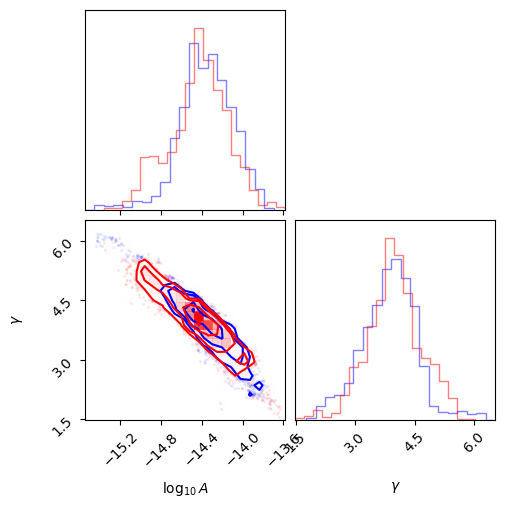

In [29]:
data_gw = {key: samples[key] for key in gw_keys}
data_ds = {key: samples_ds[key] for key in gw_keys}
labels = [r"$\log_{10} A$", r"$\gamma$"]

figure = corner.corner(data_gw, labels=labels, 
                       hist_kwargs={"density": True, "alpha": 0.5, "color": "blue"},  
                       color='blue')
corner.corner(data_ds, labels=labels, fig = figure, 
              hist_kwargs={"density": True, "alpha": 0.5, "color": "red"}, 
              color = 'red')
plt.show()

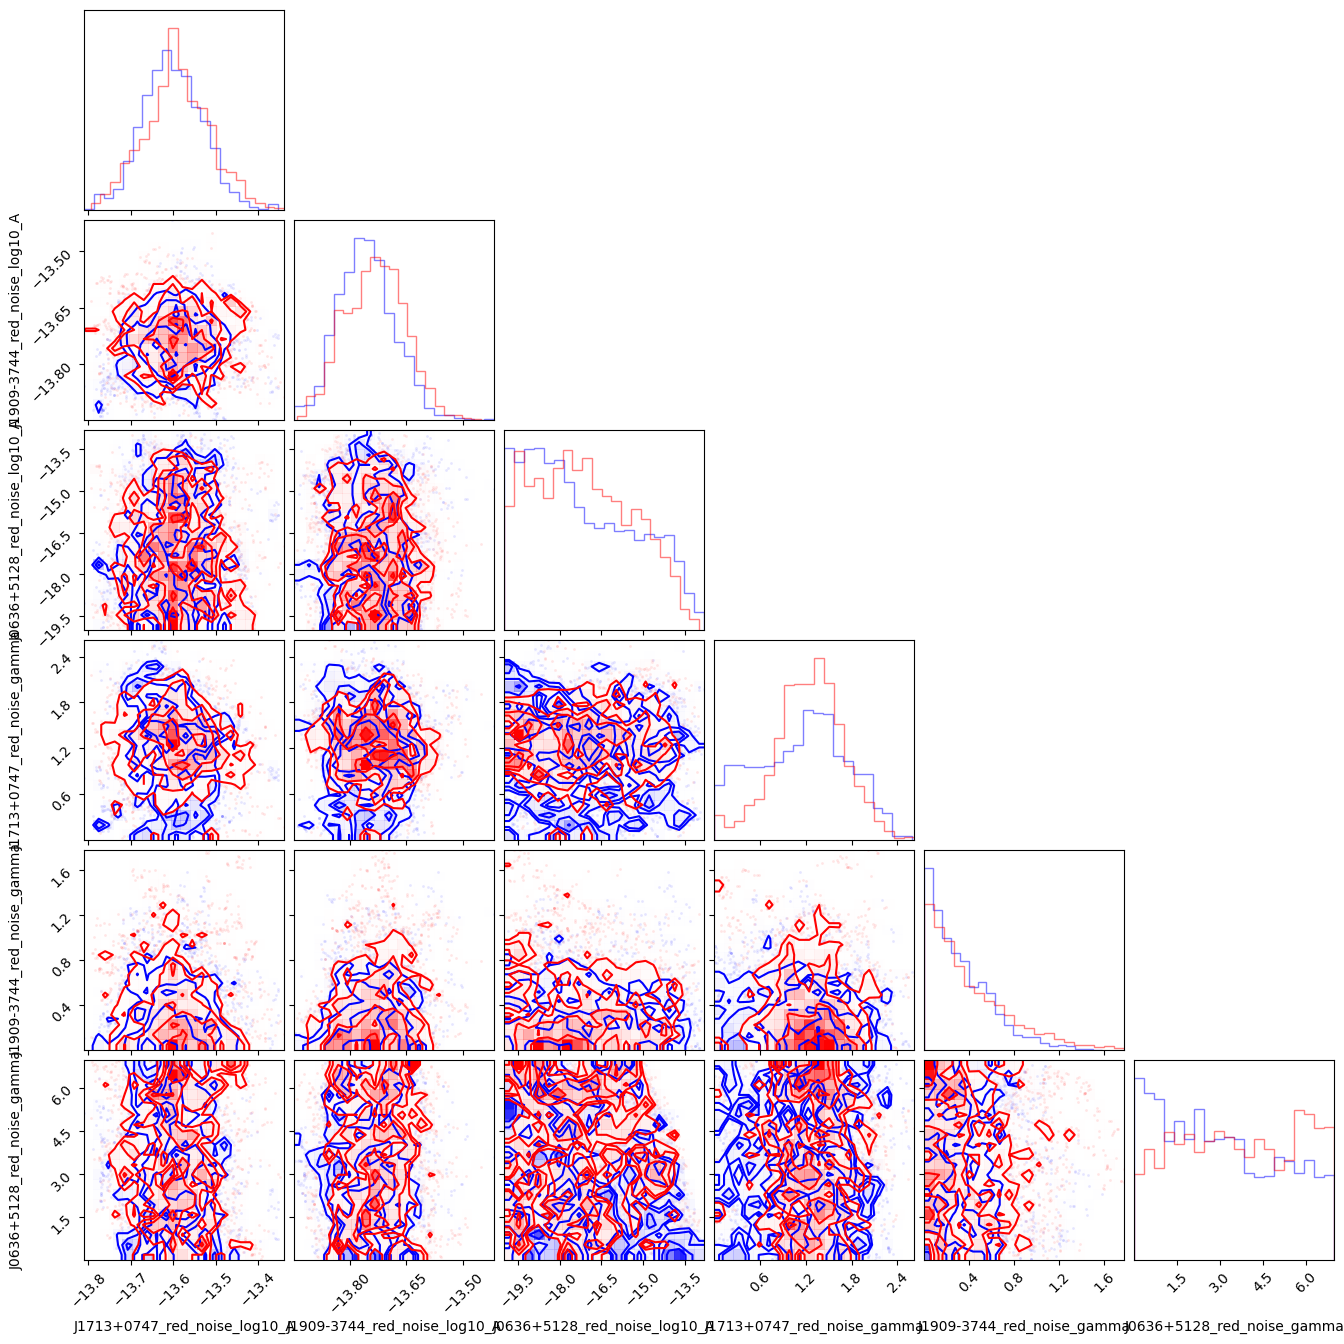

In [30]:
rn_keys = rn_amp_keys[:3] + rn_gamma_keys[:3]
data_rn = {key: samples[key] for key in rn_keys}
data_rn_ds = {key: samples_ds[key] for key in rn_keys}

figure = corner.corner(data_rn, labels=rn_keys, 
                       hist_kwargs={"density": True, "alpha": 0.5, "color": "blue"},
                       color='blue')
corner.corner(data_rn_ds, labels=rn_keys, fig = figure, 
              hist_kwargs={"density": True, "alpha": 0.5, "color": "red"}, 
              color = 'red')
plt.show()